In [121]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sehaj1104/indian-road-accident-dataset-20222025/indian_roads_dataset.csv


In [122]:
!pip install streamlit pyngrok joblib -q

In [123]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import joblib
import os

In [124]:
df = pd.read_csv("/kaggle/input/datasets/sehaj1104/indian-road-accident-dataset-20222025/indian_roads_dataset.csv")
df.head()

,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score
0,0,Pune,Maharashtra,18.680827,73.930388,2023-10-22,5:00,5,Sunday,1,...,low,32,high,weather,fatal,2,2,0,NaN,0.85
1,1,Mumbai,Maharashtra,18.817732,72.790846,2023-05-21,4:00,4,Sunday,1,...,high,34,low,weather,major,4,3,0,NaN,0.10
2,2,Mumbai,Maharashtra,19.096889,72.819424,2024-07-10,13:00,13,Wednesday,0,...,low,21,medium,weather,minor,1,1,0,NaN,0.45
3,3,Chandigarh,Punjab,30.787805,76.847507,2025-03-30,11:00,11,Sunday,1,...,low,30,high,distraction,minor,5,2,0,NaN,0.65
4,4,Chennai,Tamil Nadu,12.965155,80.283313,2024-01-25,16:00,16,Thursday,0,...,high,24,low,distraction,minor,2,1,0,NaN,0.10


In [125]:
df.ndim

2

In [126]:
df.shape

(20000, 24)

In [127]:
df.size

480000

In [128]:
df.info

<bound method DataFrame.info of        accident_id        city        state   latitude  longitude        date  \
0                0        Pune  Maharashtra  18.680827  73.930388  2023-10-22   
1                1      Mumbai  Maharashtra  18.817732  72.790846  2023-05-21   
2                2      Mumbai  Maharashtra  19.096889  72.819424  2024-07-10   
3                3  Chandigarh       Punjab  30.787805  76.847507  2025-03-30   
4                4     Chennai   Tamil Nadu  12.965155  80.283313  2024-01-25   
...            ...         ...          ...        ...        ...         ...   
19995        19995   Bangalore    Karnataka  13.092276  77.599571  2022-09-29   
19996        19996     Chennai   Tamil Nadu  13.172928  80.157062  2023-11-25   
19997        19997     Chennai   Tamil Nadu  12.997170  80.150724  2022-06-18   
19998        19998     Kolkata  West Bengal  22.454882  88.322213  2023-03-12   
19999        19999       Delhi        Delhi  28.510266  77.065301  2024-07-05

In [129]:
df.describe

<bound method NDFrame.describe of        accident_id        city        state   latitude  longitude        date  \
0                0        Pune  Maharashtra  18.680827  73.930388  2023-10-22   
1                1      Mumbai  Maharashtra  18.817732  72.790846  2023-05-21   
2                2      Mumbai  Maharashtra  19.096889  72.819424  2024-07-10   
3                3  Chandigarh       Punjab  30.787805  76.847507  2025-03-30   
4                4     Chennai   Tamil Nadu  12.965155  80.283313  2024-01-25   
...            ...         ...          ...        ...        ...         ...   
19995        19995   Bangalore    Karnataka  13.092276  77.599571  2022-09-29   
19996        19996     Chennai   Tamil Nadu  13.172928  80.157062  2023-11-25   
19997        19997     Chennai   Tamil Nadu  12.997170  80.150724  2022-06-18   
19998        19998     Kolkata  West Bengal  22.454882  88.322213  2023-03-12   
19999        19999       Delhi        Delhi  28.510266  77.065301  2024-07-

In [130]:
df.isnull().sum()

accident_id              0
city                     0
state                    0
latitude                 0
longitude                0
date                     0
time                     0
hour                     0
day_of_week              0
is_weekend               0
road_type                0
lanes                    0
traffic_signal           0
weather                  0
visibility               0
temperature              0
traffic_density          0
cause                    0
accident_severity        0
vehicles_involved        0
casualties               0
is_peak_hour             0
festival             19885
risk_score               0
dtype: int64

In [131]:
null_percentage = (
    df.isnull().sum() / len(df)
) * 100

print(null_percentage)

accident_id           0.000
city                  0.000
state                 0.000
latitude              0.000
longitude             0.000
date                  0.000
time                  0.000
hour                  0.000
day_of_week           0.000
is_weekend            0.000
road_type             0.000
lanes                 0.000
traffic_signal        0.000
weather               0.000
visibility            0.000
temperature           0.000
traffic_density       0.000
cause                 0.000
accident_severity     0.000
vehicles_involved     0.000
casualties            0.000
is_peak_hour          0.000
festival             99.425
risk_score            0.000
dtype: float64


In [132]:
df['festival'].value_counts(dropna=False)

festival
NaN         19885
Holi           38
Eid            34
Diwali         31
New Year       12
Name: count, dtype: int64

In [133]:
df['festival'].fillna('No Festival')

0        No Festival
1        No Festival
2        No Festival
3        No Festival
4        No Festival
            ...     
19995    No Festival
19996    No Festival
19997    No Festival
19998    No Festival
19999    No Festival
Name: festival, Length: 20000, dtype: object

In [134]:
df['festival'] = df['festival'].fillna('No Festival')

In [135]:
df['festival'].isnull().sum()

np.int64(0)

In [136]:
df.isnull().sum()

accident_id          0
city                 0
state                0
latitude             0
longitude            0
date                 0
time                 0
hour                 0
day_of_week          0
is_weekend           0
road_type            0
lanes                0
traffic_signal       0
weather              0
visibility           0
temperature          0
traffic_density      0
cause                0
accident_severity    0
vehicles_involved    0
casualties           0
is_peak_hour         0
festival             0
risk_score           0
dtype: int64

In [137]:
# Check all columns
print(df.columns.tolist())

['accident_id', 'city', 'state', 'latitude', 'longitude', 'date', 'time', 'hour', 'day_of_week', 'is_weekend', 'road_type', 'lanes', 'traffic_signal', 'weather', 'visibility', 'temperature', 'traffic_density', 'cause', 'accident_severity', 'vehicles_involved', 'casualties', 'is_peak_hour', 'festival', 'risk_score']


In [138]:
TARGET = "risk_score"

print(df[TARGET].describe())

count    20000.000000
mean         0.437585
std          0.218130
min          0.100000
25%          0.250000
50%          0.450000
75%          0.600000
max          1.000000
Name: risk_score, dtype: float64


In [139]:
print("Minimum risk score:", df[TARGET].min())
print("Maximum risk score:", df[TARGET].max())

Minimum risk score: 0.1
Maximum risk score: 1.0


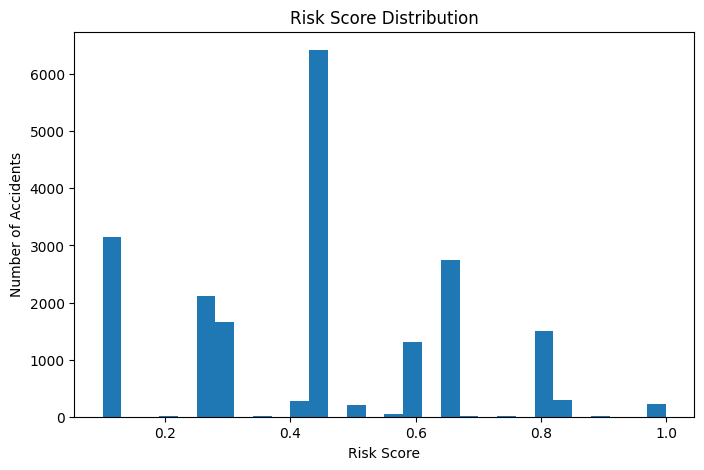

In [140]:
plt.figure(figsize=(8,5))

plt.hist(df["risk_score"], bins=30)

plt.xlabel("Risk Score")
plt.ylabel("Number of Accidents")
plt.title("Risk Score Distribution")

plt.show()

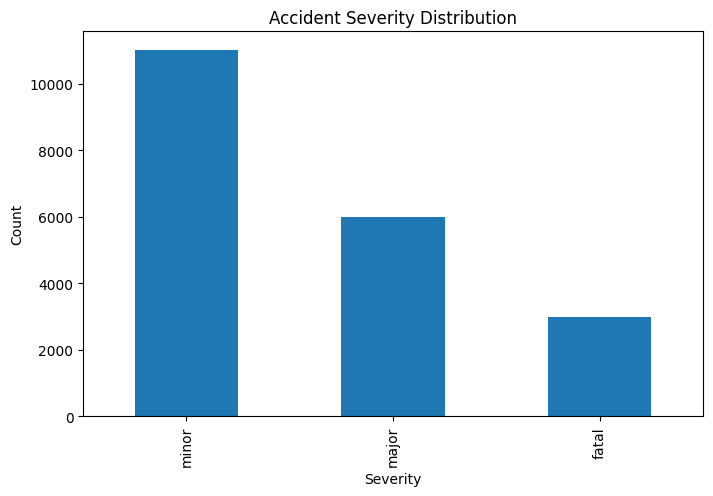

In [141]:
df["accident_severity"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Accident Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Count")

plt.show()

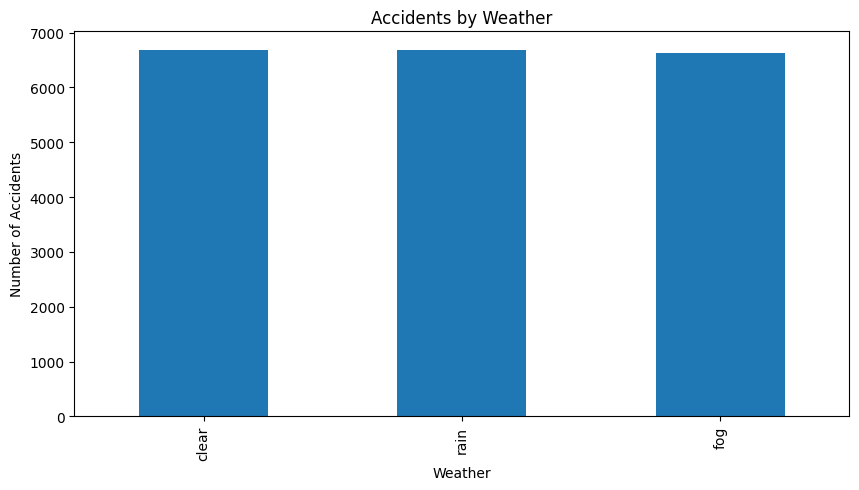

In [142]:
df["weather"].value_counts().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Accidents by Weather")
plt.xlabel("Weather")
plt.ylabel("Number of Accidents")

plt.show()

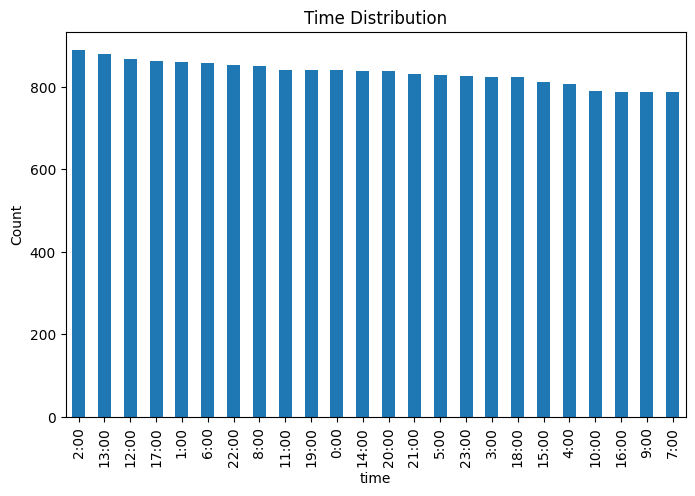

In [143]:
df["time"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Time Distribution")
plt.xlabel("time")
plt.ylabel("Count")

plt.show()

In [144]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day

df["time"] = pd.to_datetime(
    df["time"],
    errors="coerce"
)

df["time_hour"] = df["time"].dt.hour
df["time_minute"] = df["time"].dt.minute

/tmp/ipykernel_58/3568499837.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(


In [145]:
drop_columns = [
    "accident_id",
    "date",
    "time"
]

df = df.drop(
    columns=drop_columns,
    errors="ignore"
)

print(df.columns.tolist())

['city', 'state', 'latitude', 'longitude', 'hour', 'day_of_week', 'is_weekend', 'road_type', 'lanes', 'traffic_signal', 'weather', 'visibility', 'temperature', 'traffic_density', 'cause', 'accident_severity', 'vehicles_involved', 'casualties', 'is_peak_hour', 'festival', 'risk_score', 'year', 'month', 'day', 'time_hour', 'time_minute']


In [146]:
X = df.drop(columns=["risk_score"])
y = df["risk_score"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20000, 25)
y shape: (20000,)


In [147]:
categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['city', 'state', 'day_of_week', 'road_type', 'weather', 'visibility', 'traffic_density', 'cause', 'accident_severity', 'festival']

Numerical Features:
['latitude', 'longitude', 'hour', 'is_weekend', 'lanes', 'traffic_signal', 'temperature', 'vehicles_involved', 'casualties', 'is_peak_hour', 'year', 'month', 'day', 'time_hour', 'time_minute']


In [148]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (16000, 25)
Testing data: (4000, 25)


In [149]:
from sklearn.impute import SimpleImputer

In [150]:
from sklearn.preprocessing import StandardScaler

In [151]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [152]:
from sklearn.ensemble import RandomForestRegressor

In [153]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [154]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rf_model)
    ]
)

In [155]:
print("Training Random Forest...")

rf_pipeline.fit(
    X_train,
    y_train
)

print("Training completed!")

Training Random Forest...
Training completed!


In [156]:
y_pred_rf = rf_pipeline.predict(X_test)

print(y_pred_rf[:10])

[0.1  0.3  0.65 0.45 0.65 0.3  0.25 0.45 0.1  0.1 ]


In [157]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [158]:
mae = mean_absolute_error(
    y_test,
    y_pred_rf
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf
    )
)

r2 = r2_score(
    y_test,
    y_pred_rf
)

print("Random Forest Results")
print("---------------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

Random Forest Results
---------------------
MAE : 4.675000000445929e-05
RMSE: 0.0012293799250028103
R²  : 0.9999674630289467


In [159]:
from sklearn.ensemble import GradientBoostingRegressor

In [160]:
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", gb_model)
    ]
)

In [161]:
print("Training Gradient Boosting...")

gb_pipeline.fit(
    X_train,
    y_train
)

print("Training completed!")

Training Gradient Boosting...
Training completed!


In [162]:
y_pred_gb = gb_pipeline.predict(X_test)

In [163]:
mae_gb = mean_absolute_error(
    y_test,
    y_pred_gb
)

rmse_gb = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_gb
    )
)

r2_gb = r2_score(
    y_test,
    y_pred_gb
)

print("Gradient Boosting Results")
print("-------------------------")
print("MAE :", mae_gb)
print("RMSE:", rmse_gb)
print("R²  :", r2_gb)

Gradient Boosting Results
-------------------------
MAE : 0.0002907081931938648
RMSE: 0.0005888692760266514
R²  : 0.9999925347788403


In [164]:
results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        mae,
        mae_gb
    ],
    "RMSE": [
        rmse,
        rmse_gb
    ],
    "R2 Score": [
        r2,
        r2_gb
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Random Forest,0.000047,0.001229,0.999967
1,Gradient Boosting,0.000291,0.000589,0.999993


In [165]:
if r2_gb >= r2:
    best_model = gb_pipeline
    best_model_name = "Gradient Boosting"
    best_r2 = r2_gb
else:
    best_model = rf_pipeline
    best_model_name = "Random Forest"
    best_r2 = r2

print("Best Model:", best_model_name)
print("R² Score:", best_r2)

Best Model: Gradient Boosting
R² Score: 0.9999925347788403


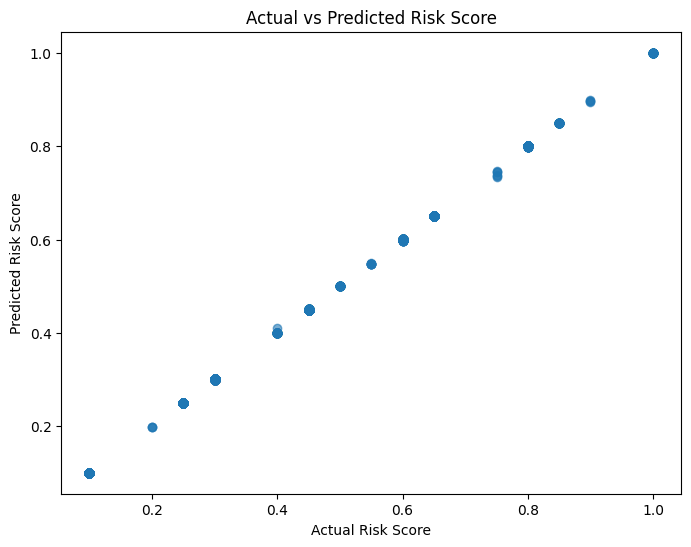

In [166]:
best_predictions = best_model.predict(X_test)

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.6
)

plt.xlabel("Actual Risk Score")
plt.ylabel("Predicted Risk Score")
plt.title("Actual vs Predicted Risk Score")

plt.show()

In [167]:
MODEL_PATH = "/kaggle/working/road_accident_risk_model.pkl"

joblib.dump(
    best_model,
    MODEL_PATH
)

print("Model saved successfully!")
print(MODEL_PATH)

Model saved successfully!
/kaggle/working/road_accident_risk_model.pkl


In [168]:
import os

print(
    "Model exists:",
    os.path.exists(MODEL_PATH)
)

Model exists: True


In [169]:
!pip install -q streamlit pyngrok

In [170]:
import streamlit

print("Streamlit version:", streamlit.__version__)

Streamlit version: 1.62.0


In [171]:
%%writefile /kaggle/working/app.py

import streamlit as st
import pandas as pd
import numpy as np
import joblib

MODEL_PATH = "/kaggle/working/road_accident_risk_model.pkl"

model = joblib.load(MODEL_PATH)

st.set_page_config(
    page_title="Road Accident Risk Prediction",
    page_icon="🚗",
    layout="wide"
)

st.title("🚗 Road Accident Risk Prediction")
st.write(
    "Enter road and environmental conditions "
    "to predict accident risk score."
)

st.divider()

col1, col2 = st.columns(2)

with col1:

    city = st.text_input(
        "City",
        value="Lucknow"
    )

    state = st.text_input(
        "State",
        value="Uttar Pradesh"
    )

    latitude = st.number_input(
        "Latitude",
        value=26.8467
    )

    longitude = st.number_input(
        "Longitude",
        value=80.9462
    )

    hour = st.slider(
        "Hour",
        min_value=0,
        max_value=23,
        value=18
    )

    day_of_week = st.selectbox(
        "Day of Week",
        [
            "Monday",
            "Tuesday",
            "Wednesday",
            "Thursday",
            "Friday",
            "Saturday",
            "Sunday"
        ]
    )

    is_weekend = st.selectbox(
        "Weekend?",
        [0, 1]
    )

    road_type = st.selectbox(
        "Road Type",
        [
            "Highway",
            "Urban",
            "Rural",
            "Residential",
            "Intersection"
        ]
    )

    lanes = st.number_input(
        "Number of Lanes",
        min_value=1,
        max_value=10,
        value=2
    )

with col2:

    traffic_signal = st.selectbox(
        "Traffic Signal",
        [0, 1]
    )

    weather = st.selectbox(
        "Weather",
        [
            "Clear",
            "Rain",
            "Fog",
            "Storm",
            "Cloudy"
        ]
    )

    visibility = st.number_input(
        "Visibility",
        min_value=0.0,
        value=10.0
    )

    temperature = st.number_input(
        "Temperature",
        value=25.0
    )

    traffic_density = st.selectbox(
        "Traffic Density",
        [
            "Low",
            "Medium",
            "High"
        ]
    )

    cause = st.selectbox(
        "Accident Cause",
        [
            "Speeding",
            "Drunk Driving",
            "Poor Road Condition",
            "Weather",
            "Driver Distraction",
            "Other"
        ]
    )

    accident_severity = st.selectbox(
        "Accident Severity",
        [
            "Minor",
            "Moderate",
            "Severe"
        ]
    )

    vehicles_involved = st.number_input(
        "Vehicles Involved",
        min_value=1,
        max_value=20,
        value=2
    )

    casualties = st.number_input(
        "Casualties",
        min_value=0,
        max_value=50,
        value=0
    )

    is_peak_hour = st.selectbox(
        "Peak Hour?",
        [0, 1]
    )

    festival = st.selectbox(
        "Festival?",
        [0, 1]
    )

st.divider()

if st.button(
    "🔮 Predict Accident Risk",
    use_container_width=True
):

    input_data = pd.DataFrame({
        "city": [city],
        "state": [state],
        "latitude": [latitude],
        "longitude": [longitude],
        "hour": [hour],
        "day_of_week": [day_of_week],
        "is_weekend": [is_weekend],
        "road_type": [road_type],
        "lanes": [lanes],
        "traffic_signal": [traffic_signal],
        "weather": [weather],
        "visibility": [visibility],
        "temperature": [temperature],
        "traffic_density": [traffic_density],
        "cause": [cause],
        "accident_severity": [accident_severity],
        "vehicles_involved": [vehicles_involved],
        "casualties": [casualties],
        "is_peak_hour": [is_peak_hour],
        "festival": [festival]
    })

    prediction = model.predict(
        input_data
    )[0]

    prediction = max(
        0,
        float(prediction)
    )

    st.success(
        "Prediction completed successfully!"
    )

    st.metric(
        "Predicted Accident Risk Score",
        f"{prediction:.2f}"
    )

    if prediction < 30:
        st.info("🟢 Low Risk")
    elif prediction < 70:
        st.warning("🟡 Medium Risk")
    else:
        st.error("🔴 High Risk")

Overwriting /kaggle/working/app.py


In [172]:
for col in categorical_features:
    print("\n", col)
    print(df[col].unique())


 city
['Pune' 'Mumbai' 'Chandigarh' 'Chennai' 'Delhi' 'Bangalore' 'Hyderabad'
 'Kolkata']

 state
['Maharashtra' 'Punjab' 'Tamil Nadu' 'Delhi' 'Karnataka' 'Telangana'
 'West Bengal']

 day_of_week
['Sunday' 'Wednesday' 'Thursday' 'Monday' 'Friday' 'Tuesday' 'Saturday']

 road_type
['highway' 'urban' 'rural']

 weather
['fog' 'clear' 'rain']

 visibility
['low' 'high' 'medium']

 traffic_density
['high' 'low' 'medium']

 cause
['weather' 'distraction' 'overspeeding' 'drunk driving' 'poor road']

 accident_severity
['fatal' 'major' 'minor']

 festival
['No Festival' 'Holi' 'Diwali' 'Eid' 'New Year']


In [173]:
import os

print(os.path.exists("/kaggle/working/app.py"))

True


In [174]:
!pip install streamlit pyngrok -q

In [175]:
import subprocess
import sys

process = subprocess.Popen(
    [
        sys.executable,
        "-m",
        "streamlit",
        "run",
        "app.py",
        "--server.port",
        "8501",
        "--server.address",
        "0.0.0.0"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

print("Streamlit started successfully!")

Streamlit started successfully!


In [176]:
print("Process ID:", process.pid)
print("Running:", process.poll() is None)

Process ID: 891
Running: True


In [177]:
from pyngrok import ngrok

# Apna actual ngrok token yahan lagao
ngrok.set_auth_token("YOUR_NGROK_AUTH_TOKEN")

public_url = ngrok.connect(8501)

print("Streamlit URL:")
print(public_url)

Streamlit URL:
NgrokTunnel: "https://lavish-gawk-obscurity.ngrok-free.dev" -> "http://localhost:8501"


In [178]:
import os

print(os.getcwd())
print(os.listdir("/kaggle/working"))

/kaggle/working
['.virtual_documents', 'app.py', 'road_accident_risk_model.pkl']


In [179]:
model = joblib.load("/kaggle/working/road_accident_risk_model.pkl")

In [180]:
import subprocess
import sys

process = subprocess.Popen(
    [
        sys.executable,
        "-m",
        "streamlit",
        "run",
        "/kaggle/working/app.py",
        "--server.port",
        "8501",
        "--server.address",
        "0.0.0.0"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

print("Streamlit started!")
print("Process ID:", process.pid)

Streamlit started!
Process ID: 900


In [181]:
print("Running:", process.poll() is None)

Running: True


In [182]:
print("Return code:", process.returncode)

stdout, stderr = process.communicate()

print("\n--- ERROR ---")
print(stderr.decode())

Return code: None

--- ERROR ---
2026-08-23 09:10:15.952 Port 8501 is not available



In [183]:
!streamlit --version

Streamlit, version 1.62.0


In [184]:
import os

print("app.py exists:", os.path.exists("/kaggle/working/app.py"))
print("model exists:", os.path.exists("/kaggle/working/road_accident_risk_model.pkl"))

app.py exists: True
model exists: True


In [185]:
with open("/kaggle/working/app.py", "r") as f:
    print(f.read())


import streamlit as st
import pandas as pd
import numpy as np
import joblib

MODEL_PATH = "/kaggle/working/road_accident_risk_model.pkl"

model = joblib.load(MODEL_PATH)

st.set_page_config(
    page_title="Road Accident Risk Prediction",
    page_icon="🚗",
    layout="wide"
)

st.title("🚗 Road Accident Risk Prediction")
st.write(
    "Enter road and environmental conditions "
    "to predict accident risk score."
)

st.divider()

col1, col2 = st.columns(2)

with col1:

    city = st.text_input(
        "City",
        value="Lucknow"
    )

    state = st.text_input(
        "State",
        value="Uttar Pradesh"
    )

    latitude = st.number_input(
        "Latitude",
        value=26.8467
    )

    longitude = st.number_input(
        "Longitude",
        value=80.9462
    )

    hour = st.slider(
        "Hour",
        min_value=0,
        max_value=23,
        value=18
    )

    day_of_week = st.selectbox(
        "Day of Week",
        [
            "Monday",
            "T

In [186]:
import subprocess
import sys

process = subprocess.Popen(
    [
        sys.executable,
        "-m",
        "streamlit",
        "run",
        "/kaggle/working/app.py",
        "--server.port",
        "8502",
        "--server.address",
        "0.0.0.0"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

print("Process ID:", process.pid)

Process ID: 914


In [187]:
print("Running:", process.poll() is None)

Running: True


In [188]:
from pyngrok import ngrok

ngrok.set_auth_token("YOUR_NGROK_AUTH_TOKEN")

public_url = ngrok.connect(8502)

print("Public URL:")
print(public_url)

Public URL:
NgrokTunnel: "https://lavish-gawk-obscurity.ngrok-free.dev" -> "http://localhost:8502"


In [189]:
from pyngrok import ngrok

ngrok.set_auth_token("3IJAdlPa4HYlmm2YoAixtuGU19n_4AaxbP3VM8HHQATZm3psp")

In [190]:
public_url = ngrok.connect(8502)

print("Public URL:")
print(public_url)

Public URL:
NgrokTunnel: "https://lavish-gawk-obscurity.ngrok-free.dev" -> "http://localhost:8502"


In [191]:
from pyngrok import ngrok

# Put your REAL ngrok authtoken here
ngrok.set_auth_token("3IJAdlPa4HYlmm2YoAixtuGU19n_4AaxbP3VM8HHQATZm3psp")

# Connect to Streamlit
public_url = ngrok.connect(8502)

print("public")
print(public_url)

public
NgrokTunnel: "https://lavish-gawk-obscurity.ngrok-free.dev" -> "http://localhost:8502"


In [192]:
import pandas as pd
from datetime import date, time

In [194]:
%%writefile /kaggle/working/app.py

import streamlit as st
import pandas as pd
import joblib
from datetime import date, time

# =========================================================
# PAGE CONFIGURATION
# =========================================================

st.set_page_config(
    page_title="Indian Road Accident Risk Prediction",
    page_icon="🚗",
    layout="wide"
)

# =========================================================
# LOAD MODEL
# =========================================================

MODEL_PATH = "/kaggle/working/road_accident_risk_model.pkl"

try:
    model = joblib.load(MODEL_PATH)
except Exception as e:
    st.error("❌ Model load nahi ho pa raha hai.")
    st.exception(e)
    st.stop()


# =========================================================
# TITLE
# =========================================================

st.title("🚗 Indian Road Accident Risk Prediction")

st.write(
    "Enter road, traffic, weather and accident-related conditions "
    "to predict the accident risk."
)

st.divider()


# =========================================================
# DATE AND TIME
# =========================================================

st.subheader("📅 Date & Time")

col1, col2 = st.columns(2)

with col1:

    selected_date = st.date_input(
        "Accident Date",
        value=date.today()
    )

with col2:

    selected_time = st.time_input(
        "Accident Time",
        value=time(12, 0)
    )


# Automatically create required time features

year = selected_date.year
month = selected_date.month
day = selected_date.day

time_hour = selected_time.hour
time_minute = selected_time.minute

# Day of week
day_of_week = selected_date.strftime("%A")

# Weekend
is_weekend = 1 if selected_date.weekday() >= 5 else 0

# Peak hour
is_peak_hour = 1 if (
    7 <= time_hour <= 10 or
    17 <= time_hour <= 20
) else 0


# =========================================================
# LOCATION
# =========================================================

st.subheader("📍 Location")

col1, col2 = st.columns(2)

with col1:

    city = st.text_input(
        "City",
        value="Varanasi"
    )

with col2:

    state = st.text_input(
        "State",
        value="Uttar Pradesh"
    )


col1, col2 = st.columns(2)

with col1:

    latitude = st.number_input(
        "Latitude",
        value=25.3176,
        format="%.6f"
    )

with col2:

    longitude = st.number_input(
        "Longitude",
        value=82.9739,
        format="%.6f"
    )


# =========================================================
# ROAD INFORMATION
# =========================================================

st.subheader("🛣️ Road Information")

col1, col2, col3 = st.columns(3)

with col1:

    road_type = st.selectbox(
        "Road Type",
        [
            "Highway",
            "Urban",
            "Rural",
            "Intersection",
            "Other"
        ]
    )

with col2:

    lanes = st.number_input(
        "Number of Lanes",
        min_value=1,
        max_value=10,
        value=2
    )

with col3:

    traffic_signal = st.selectbox(
        "Traffic Signal",
        [
            "Yes",
            "No"
        ]
    )


# =========================================================
# WEATHER INFORMATION
# =========================================================

st.subheader("🌦️ Weather Information")

col1, col2, col3 = st.columns(3)

with col1:

    weather = st.selectbox(
        "Weather",
        [
            "Clear",
            "Rain",
            "Fog",
            "Cloudy",
            "Storm",
            "Other"
        ]
    )

with col2:

    visibility = st.number_input(
        "Visibility",
        min_value=0.0,
        max_value=100.0,
        value=10.0
    )

with col3:

    temperature = st.number_input(
        "Temperature (°C)",
        min_value=-20.0,
        max_value=60.0,
        value=25.0
    )


# =========================================================
# TRAFFIC INFORMATION
# =========================================================

st.subheader("🚦 Traffic Information")

col1, col2 = st.columns(2)

with col1:

    traffic_density = st.selectbox(
        "Traffic Density",
        [
            "Low",
            "Medium",
            "High"
        ]
    )

with col2:

    vehicles_involved = st.number_input(
        "Vehicles Involved",
        min_value=1,
        max_value=50,
        value=2
    )


# =========================================================
# ACCIDENT INFORMATION
# =========================================================

st.subheader("⚠️ Other Information")

col1, col2 = st.columns(2)

with col1:

    cause = st.selectbox(
        "Possible Cause",
        [
            "Overspeeding",
            "Drunk Driving",
            "Distracted Driving",
            "Poor Road Condition",
            "Weather",
            "Mechanical Failure",
            "Other"
        ]
    )

with col2:

    festival = st.selectbox(
        "Festival / Special Event",
        [
            "No",
            "Yes"
        ]
    )


# =========================================================
# PREDICTION
# =========================================================

st.divider()

if st.button(
    "🔮 Predict Accident Risk",
    use_container_width=True
):

    # -----------------------------------------------------
    # CREATE INPUT DATAFRAME
    # -----------------------------------------------------

    input_data = pd.DataFrame({

        "city": [city],

        "state": [state],

        "latitude": [latitude],

        "longitude": [longitude],

        "date": [selected_date.strftime("%Y-%m-%d")],

        "time": [
            selected_time.strftime("%H:%M:%S")
        ],

        "hour": [time_hour],

        "day_of_week": [day_of_week],

        "is_weekend": [is_weekend],

        "road_type": [road_type],

        "lanes": [lanes],

        "traffic_signal": [traffic_signal],

        "weather": [weather],

        "visibility": [visibility],

        "temperature": [temperature],

        "traffic_density": [traffic_density],

        "cause": [cause],

        "vehicles_involved": [vehicles_involved],

        "is_peak_hour": [is_peak_hour],

        "festival": [festival],

        # Required by your trained model
        "year": [year],

        "month": [month],

        "day": [day],

        "time_hour": [time_hour],

        "time_minute": [time_minute]
    })


    # -----------------------------------------------------
    # REMOVE COLUMNS THAT SHOULD NOT BE USED
    # -----------------------------------------------------

    # accident_id is not required for prediction.
    # accident_severity is also not an input because it is
    # usually an outcome-related variable.

    # -----------------------------------------------------
    # ALIGN INPUT WITH MODEL FEATURES
    # -----------------------------------------------------

    try:

        # If model contains original training feature names
        if hasattr(model, "feature_names_in_"):

            expected_columns = list(
                model.feature_names_in_
            )

            input_data = input_data.reindex(
                columns=expected_columns
            )

        elif (
            hasattr(model, "named_steps")
            and "preprocessor" in model.named_steps
        ):

            preprocessor = model.named_steps["preprocessor"]

            if hasattr(
                preprocessor,
                "feature_names_in_"
            ):

                expected_columns = list(
                    preprocessor.feature_names_in_
                )

                input_data = input_data.reindex(
                    columns=expected_columns
                )


        # -------------------------------------------------
        # PREDICTION
        # -------------------------------------------------

        prediction = model.predict(input_data)[0]


        # -------------------------------------------------
        # RESULT
        # -------------------------------------------------

        st.subheader("🎯 Prediction Result")

        if str(prediction).lower() == "high":

            st.error(
                f"🚨 HIGH ACCIDENT RISK\n\n"
                f"Predicted Risk: {prediction}"
            )

        elif str(prediction).lower() == "medium":

            st.warning(
                f"⚠️ MEDIUM ACCIDENT RISK\n\n"
                f"Predicted Risk: {prediction}"
            )

        elif str(prediction).lower() == "low":

            st.success(
                f"✅ LOW ACCIDENT RISK\n\n"
                f"Predicted Risk: {prediction}"
            )

        else:

            st.info(
                f"Predicted Result: {prediction}"
            )


        # -------------------------------------------------
        # PROBABILITY
        # -------------------------------------------------

        if hasattr(model, "predict_proba"):

            probabilities = model.predict_proba(
                input_data
            )[0]

            classes = model.classes_

            st.subheader("📊 Prediction Probability")

            probability_df = pd.DataFrame({

                "Risk Level": classes,

                "Probability": [
                    f"{p * 100:.2f}%"
                    for p in probabilities
                ]
            })

            st.dataframe(
                probability_df,
                use_container_width=True
            )


        # -------------------------------------------------
        # INPUT SUMMARY
        # -------------------------------------------------

        with st.expander(
            "🔍 View Input Data"
        ):

            st.dataframe(
                input_data,
                use_container_width=True
            )


    except Exception as e:

        st.error(
            "❌ Prediction ke time error aaya."
        )

        st.exception(e)


# =========================================================
# FOOTER
# =========================================================

st.divider()

st.caption(
    "Road Accident Risk Prediction System | "
    "Machine Learning Project"
)

Overwriting /kaggle/working/app.py


In [195]:
from pyngrok import ngrok

ngrok.kill()

print("ngrok stopped")

ngrok stopped


In [196]:
import subprocess
import sys

process = subprocess.Popen(
    [
        sys.executable,
        "-m",
        "streamlit",
        "run",
        "/kaggle/working/app.py",
        "--server.port",
        "8502",
        "--server.address",
        "0.0.0.0"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

print("Streamlit started")
print("PID:", process.pid)

Streamlit started
PID: 948


In [197]:
print("Running:", process.poll() is None)

Running: False


In [198]:
print("Return code:", process.returncode)

stdout, stderr = process.communicate()

print("\n========== STREAMLIT ERROR ==========")
print(stderr.decode())

Return code: 1

========== STREAMLIT ERROR ==========
2026-08-23 09:12:14.840 Port 8502 is not available



In [200]:
import subprocess
import sys

process = subprocess.Popen(
    [
        sys.executable,
        "-m",
        "streamlit",
        "run",
        "/kaggle/working/app.py",
        "--server.port",
        "8510",
        "--server.address",
        "0.0.0.0"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

print("Streamlit process started")
print("PID:", process.pid)

Streamlit process started
PID: 964


In [201]:
print("Running:", process.poll() is None)

Running: False


In [202]:
from pyngrok import ngrok

# Apna REAL ngrok token use karo
ngrok.set_auth_token("3IJAdlPa4HYlmm2YoAixtuGU19n_4AaxbP3VM8HHQATZm3psp")

public_url = ngrok.connect(8510)

print("Your Streamlit URL:")
print(public_url)

Your Streamlit URL:
NgrokTunnel: "https://lavish-gawk-obscurity.ngrok-free.dev" -> "http://localhost:8510"


In [203]:
model = joblib.load(
    "/kaggle/working/road_accident_risk_model.pkl"
)

print(model.named_steps.keys())

dict_keys(['preprocessor', 'model'])


In [204]:
preprocessor = model.named_steps["preprocessor"]

print(preprocessor.transformers_)

[('num', Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())]), ['latitude', 'longitude', 'hour', 'is_weekend', 'lanes', 'traffic_signal', 'temperature', 'vehicles_involved', 'casualties', 'is_peak_hour', 'year', 'month', 'day', 'time_hour', 'time_minute']), ('cat', Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore'))]), ['city', 'state', 'day_of_week', 'road_type', 'weather', 'visibility', 'traffic_density', 'cause', 'accident_severity', 'festival'])]


In [205]:
print("Model type:", type(model))

Model type: <class 'sklearn.pipeline.Pipeline'>


In [206]:
print(model.named_steps.keys())

dict_keys(['preprocessor', 'model'])


In [209]:
preprocessor = model.named_steps["preprocessor"]

print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['latitude', 'longitude', 'hour', 'is_weekend',
                                  'lanes', 'traffic_signal', 'temperature',
                                  'vehicles_involved', 'casualties',
                                  'is_peak_hour', 'year', 'month', 'day',
                                  'time_hour', 'time_minute']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                       

In [210]:
for name, transformer, columns in preprocessor.transformers_:
    print("\n====================")
    print("Transformer:", name)
    print("Columns:", columns)


Transformer: num
Columns: ['latitude', 'longitude', 'hour', 'is_weekend', 'lanes', 'traffic_signal', 'temperature', 'vehicles_involved', 'casualties', 'is_peak_hour', 'year', 'month', 'day', 'time_hour', 'time_minute']

Transformer: cat
Columns: ['city', 'state', 'day_of_week', 'road_type', 'weather', 'visibility', 'traffic_density', 'cause', 'accident_severity', 'festival']


In [213]:
%%writefile /kaggle/working/app.py

import streamlit as st
import pandas as pd
import joblib
from datetime import date, time


# =========================================================
# PAGE CONFIG
# =========================================================

st.set_page_config(
    page_title="Indian Road Accident Risk Prediction",
    page_icon="🚗",
    layout="wide"
)


# =========================================================
# LOAD MODEL
# =========================================================

MODEL_PATH = "/kaggle/working/road_accident_risk_model.pkl"

try:
    model = joblib.load(MODEL_PATH)

except Exception as e:
    st.error("❌ Model load nahi ho raha hai.")
    st.exception(e)
    st.stop()


# =========================================================
# TITLE
# =========================================================

st.title("🚗 Indian Road Accident Risk Prediction")

st.write(
    "Enter road, traffic, weather and accident conditions "
    "to predict accident risk."
)

st.divider()


# =========================================================
# DATE & TIME
# =========================================================

st.subheader("📅 Date & Time")

col1, col2 = st.columns(2)

with col1:

    selected_date = st.date_input(
        "Accident Date",
        value=date.today()
    )

with col2:

    selected_time = st.time_input(
        "Accident Time",
        value=time(12, 0)
    )


# Create date features

year = selected_date.year
month = selected_date.month
day = selected_date.day

time_hour = selected_time.hour
time_minute = selected_time.minute

day_of_week = selected_date.strftime("%A")

# Weekend

is_weekend = 1 if selected_date.weekday() >= 5 else 0

# Peak hour

is_peak_hour = (
    1
    if (7 <= time_hour <= 10 or 17 <= time_hour <= 20)
    else 0
)


# =========================================================
# LOCATION
# =========================================================

st.subheader("📍 Location")

col1, col2 = st.columns(2)

with col1:

    city = st.text_input(
        "City",
        value="Varanasi"
    )

with col2:

    state = st.text_input(
        "State",
        value="Uttar Pradesh"
    )


col1, col2 = st.columns(2)

with col1:

    latitude = st.number_input(
        "Latitude",
        value=25.3176,
        format="%.6f"
    )

with col2:

    longitude = st.number_input(
        "Longitude",
        value=82.9739,
        format="%.6f"
    )


# =========================================================
# ROAD INFORMATION
# =========================================================

st.subheader("🛣️ Road Information")

col1, col2, col3 = st.columns(3)

with col1:

    road_type = st.selectbox(
        "Road Type",
        [
            "highway",
            "urban",
            "rural"
        ]
    )

with col2:

    lanes = st.number_input(
        "Number of Lanes",
        min_value=1,
        max_value=10,
        value=2
    )

with col3:

    traffic_signal_text = st.selectbox(
        "Traffic Signal",
        [
            "No",
            "Yes"
        ]
    )

# IMPORTANT:
# Model expects numeric 0/1

traffic_signal = (
    1 if traffic_signal_text == "Yes"
    else 0
)


# =========================================================
# WEATHER INFORMATION
# =========================================================

st.subheader("🌦️ Weather Information")

col1, col2, col3 = st.columns(3)

with col1:

    weather = st.selectbox(
        "Weather",
        [
            "clear",
            "rain",
            "fog"
        ]
    )

with col2:

    visibility = st.selectbox(
        "Visibility",
        [
            "low",
            "medium",
            "high"
        ]
    )

with col3:

    temperature = st.number_input(
        "Temperature (°C)",
        min_value=-20.0,
        max_value=60.0,
        value=25.0
    )


# =========================================================
# TRAFFIC INFORMATION
# =========================================================

st.subheader("🚦 Traffic Information")

col1, col2 = st.columns(2)

with col1:

    traffic_density = st.selectbox(
        "Traffic Density",
        [
            "low",
            "medium",
            "high"
        ]
    )

with col2:

    vehicles_involved = st.number_input(
        "Vehicles Involved",
        min_value=1,
        max_value=50,
        value=2
    )


# =========================================================
# ACCIDENT INFORMATION
# =========================================================

st.subheader("⚠️ Accident Information")

col1, col2 = st.columns(2)

with col1:

    cause = st.selectbox(
        "Possible Cause",
        [
            "weather",
            "distraction",
            "overspeeding",
            "drunk driving",
            "poor road"
        ]
    )

with col2:

    accident_severity = st.selectbox(
        "Accident Severity",
        [
            "minor",
            "major",
            "fatal"
        ]
    )


# =========================================================
# FESTIVAL
# =========================================================

festival = st.selectbox(
    "Festival / Special Event",
    [
        "No Festival",
        "Holi",
        "Diwali",
        "Eid",
        "New Year"
    ]
)


# =========================================================
# PREDICTION BUTTON
# =========================================================

st.divider()

if st.button(
    "🔮 Predict Accident Risk",
    use_container_width=True
):

    # =====================================================
    # CREATE INPUT DATA
    # =====================================================

    input_data = pd.DataFrame({

        "latitude": [latitude],

        "longitude": [longitude],

        "hour": [time_hour],

        "is_weekend": [is_weekend],

        "lanes": [lanes],

        "traffic_signal": [traffic_signal],

        "temperature": [temperature],

        "vehicles_involved": [vehicles_involved],

        # IMPORTANT:
        # casualties was used during training
        # so we need a value here
        "casualties": [0],

        "is_peak_hour": [is_peak_hour],

        "year": [year],

        "month": [month],

        "day": [day],

        "time_hour": [time_hour],

        "time_minute": [time_minute],

        "city": [city],

        "state": [state],

        "day_of_week": [day_of_week],

        "road_type": [road_type],

        "weather": [weather],

        "visibility": [visibility],

        "traffic_density": [traffic_density],

        "cause": [cause],

        "accident_severity": [accident_severity],

        "festival": [festival]
    })


    # =====================================================
    # ALIGN WITH TRAINING COLUMNS
    # =====================================================

    try:

        preprocessor = model.named_steps["preprocessor"]

        expected_columns = (
            list(preprocessor.feature_names_in_)
        )

        input_data = input_data.reindex(
            columns=expected_columns
        )


        # =================================================
        # PREDICTION
        # =================================================
        # =================================================
        # PREDICTION
        # =================================================

        prediction = float(model.predict(input_data)[0])

        risk_percentage = prediction * 100

        st.subheader("🎯 Accident Risk Prediction")

        st.metric(
            "Risk Score",
            f"{risk_percentage:.2f}%"
        )

        if prediction < 0.33:

            st.success(
                f"🟢 LOW RISK\n\n"
                f"Risk Score: {risk_percentage:.2f}%"
            )

        elif prediction < 0.67:

            st.warning(
                f"🟡 MEDIUM RISK\n\n"
                f"Risk Score: {risk_percentage:.2f}%"
            )

        else:

            st.error(
                f"🔴 HIGH RISK\n\n"
                f"Risk Score: {risk_percentage:.2f}%"
            )


        # =================================================
        # INPUT DATA
        # =================================================

        with st.expander("🔍 View Input Data"):

            st.dataframe(
                input_data,
                use_container_width=True
            )


    except Exception as e:

        st.error(
            "❌ Prediction ke time error aaya."
        )

        st.exception(e)


# =========================================================
# FOOTER
# =========================================================

st.divider()

st.caption(
    "Indian Road Accident Risk Prediction | "
    "Machine Learning Project"
)

Overwriting /kaggle/working/app.py


In [214]:
print("Running:", process.poll() is None)

Running: False


In [215]:
!python -m py_compile /kaggle/working/app.py

In [216]:
from pyngrok import ngrok

for tunnel in ngrok.get_tunnels():
    print(tunnel.public_url)

https://lavish-gawk-obscurity.ngrok-free.dev
